# Delhi air quality: exploratory data analysis

Everything below is computed live from the project database (Open-Meteo / CAMS model series,
hourly, UTC). The goal is to learn what the data can and cannot support **before** modelling it.
Section 0 lists the findings; the sections after it show the evidence.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from pipeline.db import get_engine, read_observations
from pipeline.aqi import compute_aqi, BASES, CATEGORIES
from pipeline.locations import CELLS, NEIGHBOURHOODS

plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .25, "axes.titlesize": 12, "font.size": 10})
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#898781"

engine = get_engine()
north = read_observations(engine, "delhi-north")
south = read_observations(engine, "delhi-south")
city = read_observations(engine, "delhi")
pm = city["pm2_5"]
ist = city.copy(); ist.index = ist.index + pd.Timedelta(hours=5, minutes=30)   # IST view for human-facing cuts

## 0. Findings

In [2]:
diwali = {2022: "2022-10-24", 2023: "2023-11-12", 2024: "2024-11-01", 2025: "2025-10-20"}
bump = []
for y, d in diwali.items():
    t0 = pd.Timestamp(d)
    pre = pm.loc[t0 - pd.Timedelta(days=8): t0 - pd.Timedelta(days=1)].mean()
    peak = pm.loc[t0 - pd.Timedelta(days=1): t0 + pd.Timedelta(days=2)].max()
    bump.append((y, pre, peak, peak / pre))
bump = pd.DataFrame(bump, columns=["year", "pre_week_mean", "peak_within_-1..+2d", "ratio"]).set_index("year")
monthly = pm.groupby(pm.index.month).mean()
ratio = (city["pm10"] / city["pm2_5"]).resample("MS").mean()
winter_ratio = ratio[ratio.index.month.isin([12, 1])]
spring_ratio = ratio[ratio.index.month.isin([4, 5])]
corr = pd.concat([north["pm2_5"], south["pm2_5"]], axis=1).corr().iloc[0, 1]
full = compute_aqi(city, BASES["all"])
cat_pm25 = compute_aqi(city, BASES["pm2_5"])["category"].value_counts(normalize=True)

display(Markdown(f'''
**Data window:** {city.index.min():%d %b %Y} to {city.index.max():%d %b %Y %H:%M} UTC, {len(city):,} hourly rows per series,
PM2.5 missing in {city["pm2_5"].isna().mean():.2%} of hours.

1. **Delhi is only two independent model cells.** 21 neighbourhoods collapse onto 2 identical series
   (north/central and south), correlated {corr:.2f} in PM2.5. Per-neighbourhood or per-station forecasts
   from this source would be fiction; the project forecasts the two cells and their average.
2. **Strong, regular seasonality.** Mean PM2.5 is {monthly[[12,1]].mean():.0f} ug/m3 in Dec-Jan against {monthly[[7,8,9]].mean():.0f} in Jul-Sep
   ({monthly[[12,1]].mean()/monthly[[7,8,9]].mean():.1f}x), and {(pm.resample("D").mean() > 60).mean():.0%} of days exceed the Indian 24-hour PM2.5 standard of 60.
3. **A daily rhythm of {ist["pm2_5"].groupby(ist.index.hour).mean().max()/ist["pm2_5"].groupby(ist.index.hour).mean().min():.1f}x.** The dirtiest IST hour is
   {ist["pm2_5"].groupby(ist.index.hour).mean().idxmax()}:00 and the cleanest {ist["pm2_5"].groupby(ist.index.hour).mean().idxmin()}:00 (the mixing layer collapses after sunset).
4. **The Diwali signal is weak and inconsistent in this model.** Peak PM2.5 in the 4-day window around Diwali was
   {bump["ratio"].min():.1f}x to {bump["ratio"].max():.1f}x the previous week's mean ({", ".join(f"{y}: {r:.1f}x" for y, r in bump["ratio"].items())}).
   Ground-sensor reports usually describe much sharper Diwali spikes (not verified here: no ground data yet). A coarse model grid cannot resolve local fireworks, so a Diwali flag stays in the features but should not be expected to explain much.
5. **The model series has regime changes.** PM10/PM2.5 is {winter_ratio.loc[:"2023-12"].mean():.2f} in winter 2022-23 but {winter_ratio.loc["2024-12":].mean():.2f} in later winters
   (PM10 almost equals PM2.5, physically odd), and {spring_ratio.loc[:"2023-12"].mean():.1f} in spring 2023 versus {spring_ratio.loc["2025-01":].mean():.1f} since 2025 (dust).
   Consistent with CAMS model upgrades. Walk-forward evaluation must therefore span the break and the README must say so.
6. **Counting all six pollutants misleads.** With the official six-pollutant NAQI, ozone is the dominant pollutant in {full["dominant"].eq("o3").mean():.0%} of hours,
   and PM10 dust pushes spring to "Severe". The headline AQI therefore uses PM2.5 by default (`AQI_BASIS`), where categories are:
   {", ".join(f"{k} {v:.0%}" for k, v in cat_pm25.items())}.
7. **Boundary-layer height has a hole:** {int(city["blh"].isna().sum()):,} missing hours (Jan-Jun 2024 plus the latest days before the archive catches up).
   LightGBM handles missing values natively, but the feature carries less information than the others.
'''))


**Data window:** 04 Aug 2022 to 02 Oct 2026 18:00 UTC, 36,499 hourly rows per series,
PM2.5 missing in 0.00% of hours.

1. **Delhi is only two independent model cells.** 21 neighbourhoods collapse onto 2 identical series
   (north/central and south), correlated 0.84 in PM2.5. Per-neighbourhood or per-station forecasts
   from this source would be fiction; the project forecasts the two cells and their average.
2. **Strong, regular seasonality.** Mean PM2.5 is 117 ug/m3 in Dec-Jan against 52 in Jul-Sep
   (2.3x), and 60% of days exceed the Indian 24-hour PM2.5 standard of 60.
3. **A daily rhythm of 1.8x.** The dirtiest IST hour is
   22:00 and the cleanest 15:00 (the mixing layer collapses after sunset).
4. **The Diwali signal is weak and inconsistent in this model.** Peak PM2.5 in the 4-day window around Diwali was
   1.2x to 2.1x the previous week's mean (2022: 1.5x, 2023: 1.2x, 2024: 1.3x, 2025: 2.1x).
   Ground-sensor reports usually describe much sharper Diwali spikes (not verified here: no ground data yet). A coarse model grid cannot resolve local fireworks, so a Diwali flag stays in the features but should not be expected to explain much.
5. **The model series has regime changes.** PM10/PM2.5 is 1.51 in winter 2022-23 but 1.03 in later winters
   (PM10 almost equals PM2.5, physically odd), and 1.8 in spring 2023 versus 5.7 since 2025 (dust).
   Consistent with CAMS model upgrades. Walk-forward evaluation must therefore span the break and the README must say so.
6. **Counting all six pollutants misleads.** With the official six-pollutant NAQI, ozone is the dominant pollutant in 53% of hours,
   and PM10 dust pushes spring to "Severe". The headline AQI therefore uses PM2.5 by default (`AQI_BASIS`), where categories are:
   Satisfactory 36%, Moderate 26%, Poor 17%, Very Poor 16%, Good 5%, Severe 0%.
7. **Boundary-layer height has a hole:** 4,507 missing hours (Jan-Jun 2024 plus the latest days before the archive catches up).
   LightGBM handles missing values natively, but the feature carries less information than the others.


## 1. Coverage and gaps

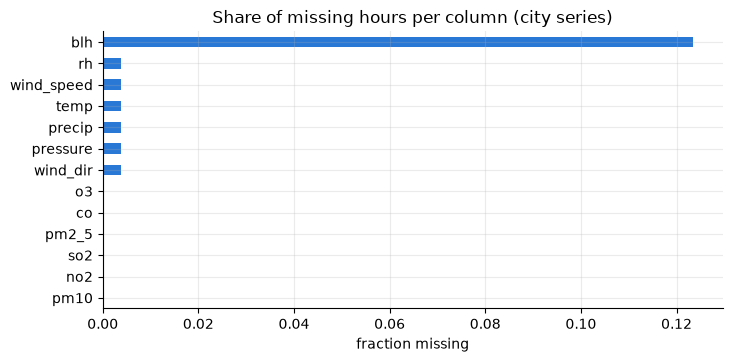

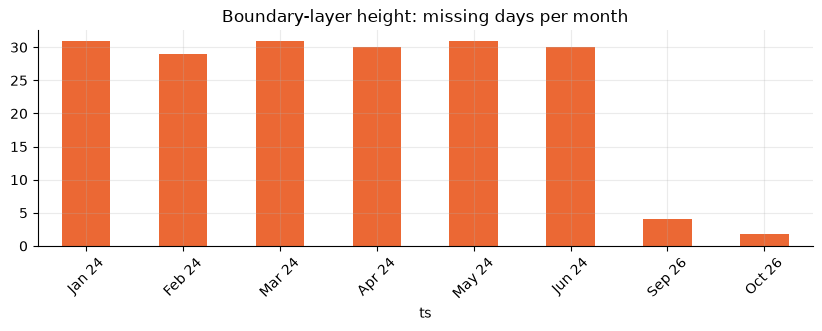

In [3]:
nulls = city.isna().mean().sort_values(ascending=False)
ax = nulls.plot.barh(color=BLUE, figsize=(8, 3.6)); ax.set_title("Share of missing hours per column (city series)")
ax.set_xlabel("fraction missing"); ax.invert_yaxis(); plt.show()
gap = city["blh"].isna().resample("MS").sum()
ax = (gap[gap > 0] / 24).plot.bar(color=ORANGE, figsize=(10, 2.8)); ax.set_title("Boundary-layer height: missing days per month")
ax.set_xticklabels([d.strftime("%b %y") for d in gap[gap > 0].index], rotation=45); plt.show()

## 2. Spatial resolution: how many Delhis are there?

The same query for 21 neighbourhoods returns **identical** series inside a grid cell
(`python scripts/check_grid_cells.py` reproduces this against the live API).

,neighbourhood
model cell,
delhi-north,"Anand Vihar, ITO / Central Delhi, Mandir Marg,..."
delhi-south,"Lodhi Road, Dwarka, Mathura Road, R.K. Puram, ..."


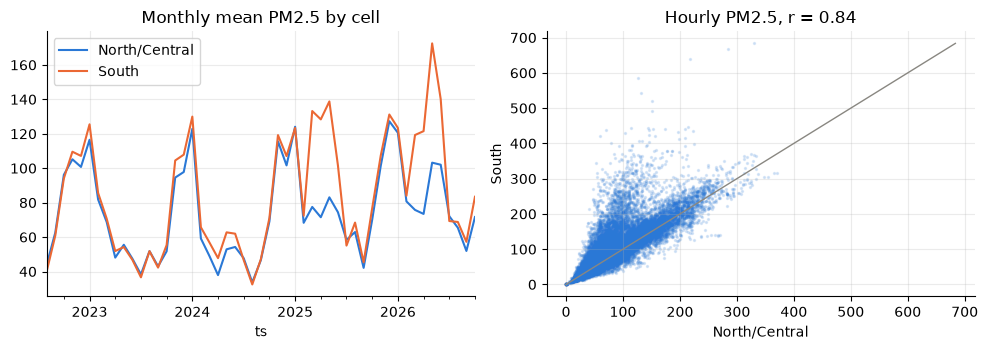

In [4]:
members = pd.DataFrame([(n.name, n.cell) for n in NEIGHBOURHOODS], columns=["neighbourhood", "model cell"])
display(members.groupby("model cell")["neighbourhood"].apply(", ".join).to_frame())
both = pd.concat({"North/Central": north["pm2_5"], "South": south["pm2_5"]}, axis=1)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
both.resample("MS").mean().plot(ax=ax[0], color=[BLUE, ORANGE]); ax[0].set_title("Monthly mean PM2.5 by cell")
ax[1].scatter(both["North/Central"], both["South"], s=2, alpha=.15, color=BLUE)
lim = [0, both.max().max()]; ax[1].plot(lim, lim, color=GREY, lw=1); ax[1].set_title(f"Hourly PM2.5, r = {corr:.2f}")
ax[1].set_xlabel("North/Central"); ax[1].set_ylabel("South"); plt.tight_layout(); plt.show()

## 3. Seasonality: year, day, and the seasonal heatmap

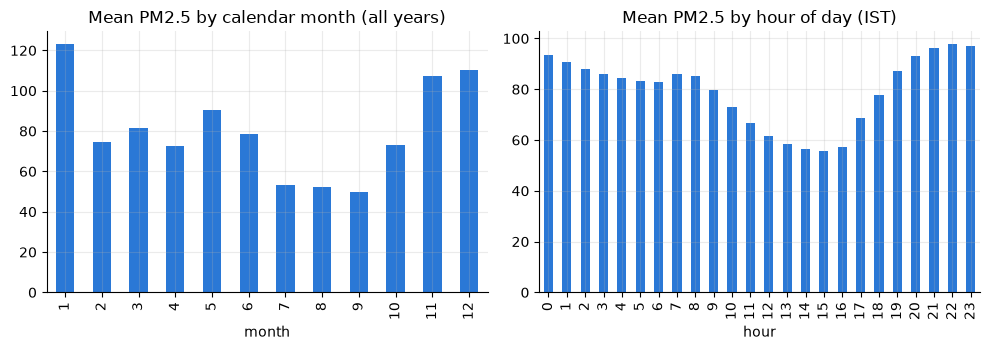

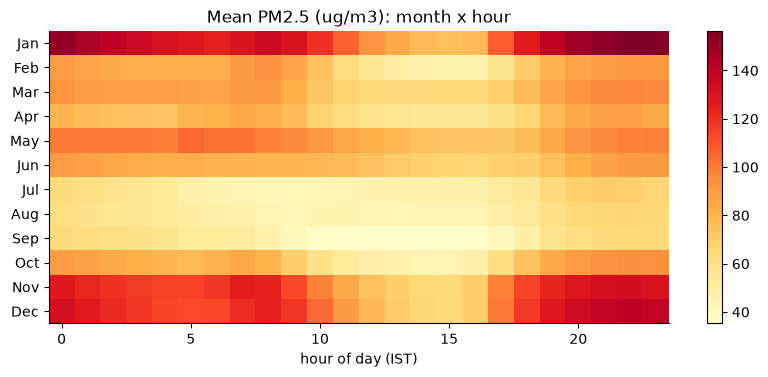

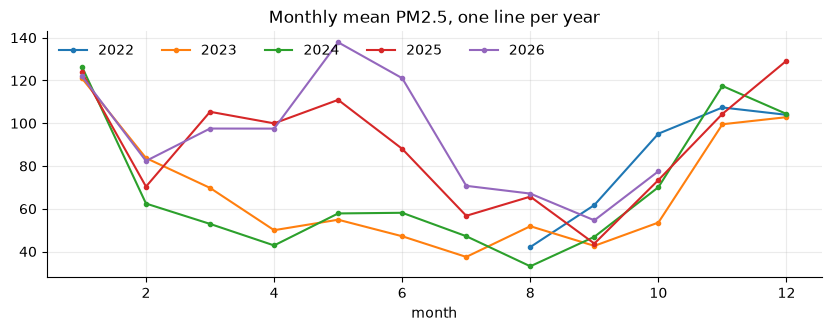

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
monthly.plot.bar(ax=ax[0], color=BLUE); ax[0].set_title("Mean PM2.5 by calendar month (all years)"); ax[0].set_xlabel("month")
hod = ist["pm2_5"].groupby(ist.index.hour).mean()
hod.plot.bar(ax=ax[1], color=BLUE); ax[1].set_title("Mean PM2.5 by hour of day (IST)"); ax[1].set_xlabel("hour")
plt.tight_layout(); plt.show()
heat = ist["pm2_5"].groupby([ist.index.month, ist.index.hour]).mean().unstack()
fig, ax = plt.subplots(figsize=(10, 3.8)); im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(12)); ax.set_yticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_xlabel("hour of day (IST)"); ax.set_title("Mean PM2.5 (ug/m3): month x hour"); ax.grid(False); plt.colorbar(im); plt.show()
yr = pm.resample("MS").mean()
fig, ax = plt.subplots(figsize=(10, 3.2))
for y, s in yr.groupby(yr.index.year):
    ax.plot(s.index.month, s.values, marker="o", ms=3, label=str(y))
ax.set_title("Monthly mean PM2.5, one line per year"); ax.set_xlabel("month"); ax.legend(ncol=5, frameon=False); plt.show()

## 4. Diwali event study

For each year: PM2.5 from 10 days before to 6 days after the main Diwali night (all times UTC).

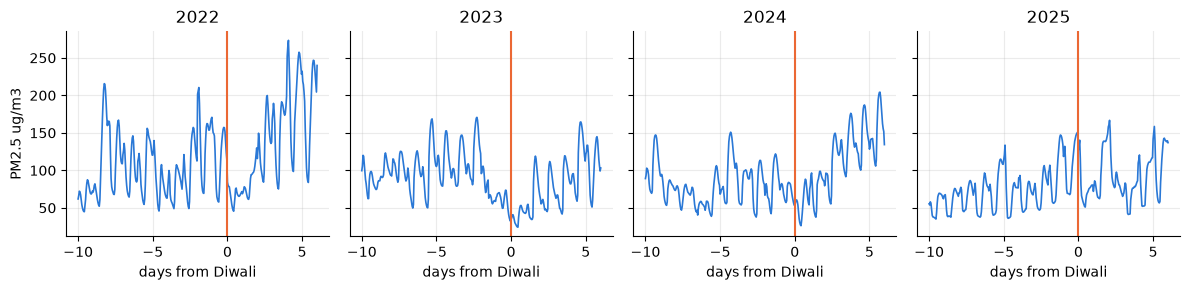

,pre_week_mean,peak_within_-1..+2d,ratio
year,,,
2022,107.0,157.6,1.5
2023,103.1,119.0,1.2
2024,77.9,98.8,1.3
2025,74.8,158.1,2.1


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for ax, (y, d) in zip(axes, diwali.items()):
    t0 = pd.Timestamp(d)
    w = pm.loc[t0 - pd.Timedelta(days=10): t0 + pd.Timedelta(days=6)]
    ax.plot((w.index - t0) / pd.Timedelta(days=1), w.values, color=BLUE, lw=1.2)
    ax.axvline(0, color=ORANGE, lw=1.5); ax.set_title(str(y)); ax.set_xlabel("days from Diwali")
axes[0].set_ylabel("PM2.5 ug/m3"); plt.tight_layout(); plt.show()
display(bump.round(1))

## 5. Regime changes in the model series

PM10 / PM2.5 should sit around 1.5 to 2 in Delhi (a coarse fraction exists). Plotting it by month reveals
how the underlying CAMS model changed behaviour over time.

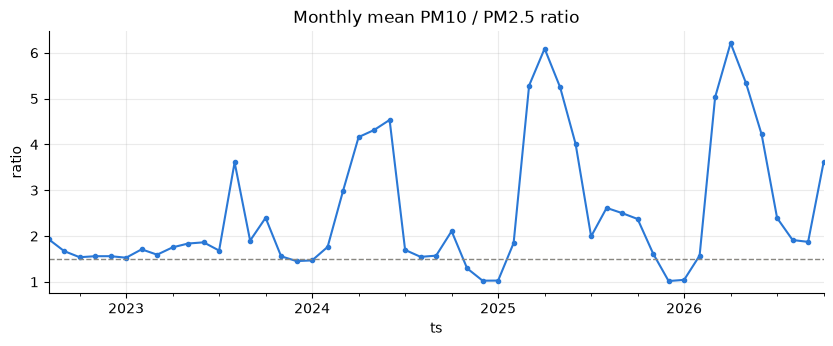

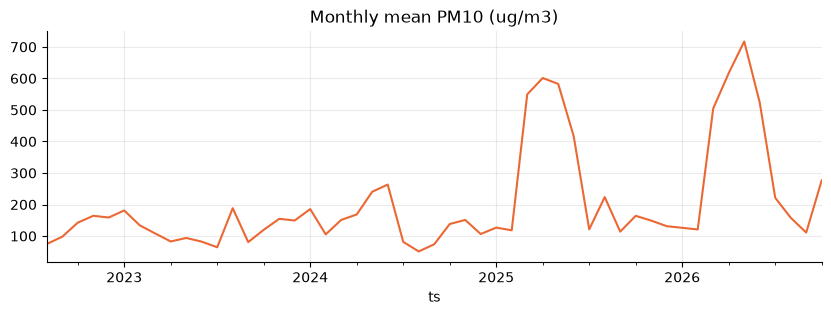

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.4))
ratio.plot(ax=ax, color=BLUE, marker="o", ms=3); ax.axhline(1.5, color=GREY, lw=1, ls="--")
ax.set_title("Monthly mean PM10 / PM2.5 ratio"); ax.set_ylabel("ratio"); plt.show()
pm10m = city["pm10"].resample("MS").mean()
ax = pm10m.plot(figsize=(10, 3), color=ORANGE); ax.set_title("Monthly mean PM10 (ug/m3)"); plt.show()

## 6. Which pollutants should set the AQI?

The NAQI takes the maximum sub-index over pollutants. If the model's ozone or dust is biased high, that maximum is
dominated by artefacts.

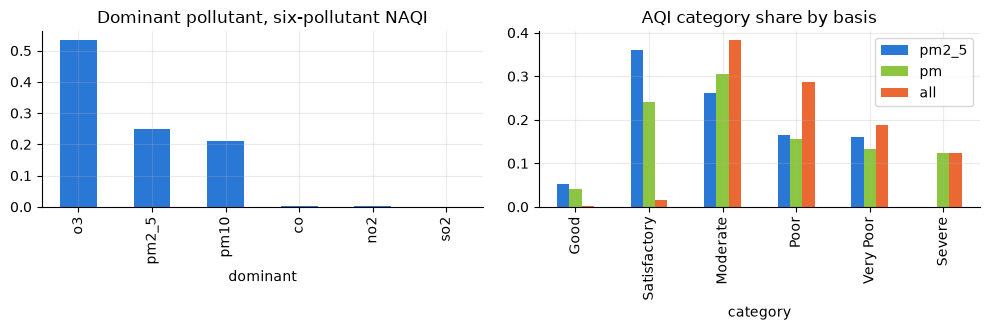

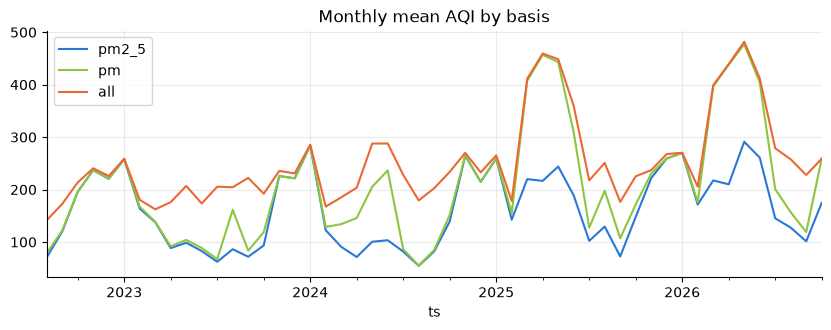

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
full["dominant"].value_counts(normalize=True).plot.bar(ax=ax[0], color=BLUE); ax[0].set_title("Dominant pollutant, six-pollutant NAQI")
tbl = pd.DataFrame({b: compute_aqi(city, BASES[b])["category"].value_counts(normalize=True) for b in BASES}).reindex([c.name for c in CATEGORIES]).fillna(0)
tbl.plot.bar(ax=ax[1], color=[BLUE, "#8cc63f", ORANGE]); ax[1].set_title("AQI category share by basis"); plt.tight_layout(); plt.show()
a = {b: compute_aqi(city, BASES[b])["aqi"].resample("MS").mean() for b in BASES}
ax = pd.DataFrame(a).plot(figsize=(10, 3.2), color=[BLUE, "#8cc63f", ORANGE]); ax.set_title("Monthly mean AQI by basis"); plt.show()

## 7. Memory and the persistence baseline

A forecast is only worth publishing if it beats "assume nothing changes". This previews how hard that is.

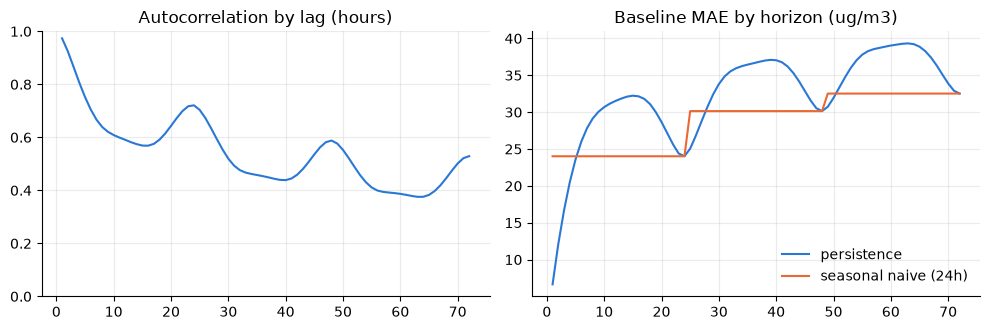

Persistence MAE: **6.6** at 1 h, **24.0** at 24 h, **32.5** at 72 h. Seasonal naive: 24.0 / 24.0 / 32.5. The models in `ml/` must beat the better of the two at every horizon.

In [9]:
y = pm.dropna()
ac = [y.autocorr(l) for l in range(1, 73)]
persist = [float((pm - pm.shift(h)).abs().mean()) for h in range(1, 73)]
seas = [float((pm - pm.shift(24 * int(np.ceil(h / 24)))).abs().mean()) for h in range(1, 73)]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(range(1, 73), ac, color=BLUE); ax[0].set_title("Autocorrelation by lag (hours)"); ax[0].set_ylim(0, 1)
ax[1].plot(range(1, 73), persist, color=BLUE, label="persistence"); ax[1].plot(range(1, 73), seas, color=ORANGE, label="seasonal naive (24h)")
ax[1].set_title("Baseline MAE by horizon (ug/m3)"); ax[1].legend(frameon=False); plt.tight_layout(); plt.show()
display(Markdown(f"Persistence MAE: **{persist[0]:.1f}** at 1 h, **{persist[23]:.1f}** at 24 h, **{persist[71]:.1f}** at 72 h. "
                 f"Seasonal naive: {seas[0]:.1f} / {seas[23]:.1f} / {seas[71]:.1f}. The models in `ml/` must beat the better of the two at every horizon."))

## What this means for the project

* Forecast **PM2.5 and PM10 for the 2 model cells and the city average**, not for 20 neighbourhoods.
* Headline AQI from **PM2.5** by default; the full six-pollutant NAQI is implemented and selectable.
* Evaluate **walk-forward across the regime changes**, report per-horizon error against both baselines, and
  report season-specific error (winter versus the rest), because the average hides the hard cases.
* Treat Diwali and stubble flags as weak features; real fire counts are not available (documented limitation).